# ICBC Road Safety Analysis - Modelling

## Introduction

This notebook builds on the EDA findings from `02_icbc_eda.ipynb` to quantify which features
independently predict casualty crash risk using two approaches:

1. **Logistic Regression (inference)** - produces odds ratios, p-values, and confidence intervals.
   Answers: *which features have the strongest independent effect on casualty risk after controlling for everything else?*

2. **XGBoost (prediction)** - optimised for classification accuracy. Produces feature importance scores.
   Answers: *which features are most useful for predicting whether a crash results in a casualty?*

| Step | Description |
|------|-------------|
| 0 | Imports & setup |
| 1 | Load & prepare data |
| 2 | Feature engineering (region mapping, encoding) |
| 3 | Handle class imbalance |
| 4 | Logistic Regression - inference |
| 5 | XGBoost - prediction |
| 6 | Model comparison & summary |


In [4]:
# pip install statsmodels xgboost scikit-learn

## 0. Imports & Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                              RocCurveDisplay, f1_score)
import xgboost as xgb

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

C_BLUE = '#2E75B6'; C_RED = '#C0392B'; C_ORANGE = '#E67E22'
C_GREEN = '#27AE60'; C_GREY = '#7F8C8D'

INPUT_CSV = 'output/icbc_cleaned_enriched.csv'
OUTPUT_DIR = 'output'


## 1. Load & Prepare Data

In [12]:
df = pd.read_csv(INPUT_CSV, low_memory=False)

for col in ['year','month','hour_approx','is_casualty','is_vulnerable','intersection','is_weekend']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['road_user_type','season','crash_config','municipality','day_of_week']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print(f'Shape: {df.shape}')
print(f'Casualty rate: {df["is_casualty"].mean()*100:.1f}%')


Shape: (1368385, 38)
Casualty rate: 17.8%


## 2. Feature Engineering

### 2.1 Region Mapping

In [14]:
metro_van = {'VANCOUVER','SURREY','BURNABY','RICHMOND','COQUITLAM','NORTH VANCOUVER',
    'DELTA','NEW WESTMINSTER','LANGLEY','MAPLE RIDGE','WEST VANCOUVER',
    'PORT COQUITLAM','PORT MOODY','PITT MEADOWS','WHITE ROCK','LANGLEY CITY',
    'NORTH VANCOUVER CITY','BOWEN ISLAND'}
fraser_valley = {'ABBOTSFORD','CHILLIWACK','MISSION','HOPE','AGASSIZ',
    'HARRISON HOT SPRINGS','KENT','DEROCHE','DEWDNEY'}
van_island = {'VICTORIA','SAANICH','NANAIMO','OAK BAY','VIEW ROYAL','LANGFORD','COLWOOD',
    'ESQUIMALT','CAMPBELL RIVER','COURTENAY','COMOX','PARKSVILLE','QUALICUM BEACH',
    'PORT ALBERNI','DUNCAN','LADYSMITH','LAKE COWICHAN','SOOKE','SIDNEY'}
interior = {'KELOWNA','KAMLOOPS','PRINCE GEORGE','VERNON','PENTICTON','MERRITT',
    'CASTLEGAR','WEST KELOWNA','LAKE COUNTRY','SALMON ARM','REVELSTOKE',
    'CRANBROOK','TRAIL','NELSON','WILLIAMS LAKE','QUESNEL','100 MILE HOUSE',
    'PEACHLAND','SUMMERLAND','OLIVER','OSOYOOS'}

def map_region(muni):
    m = str(muni).upper().strip()
    if m in metro_van:     return 'Metro Vancouver'
    if m in fraser_valley: return 'Fraser Valley'
    if m in van_island:    return 'Vancouver Island'
    if m in interior:      return 'Interior'
    return 'Northern/Other'

df['region'] = df['municipality'].apply(map_region)
display(Markdown('**Region distribution:**'))
display(df['region'].value_counts().reset_index())


**Region distribution:**

,region,count
0,Metro Vancouver,776907
1,Interior,188598
2,Vancouver Island,161135
3,Northern/Other,155115
4,Fraser Valley,86630


### 2.2 Crash Config Grouping

In [19]:
df['crash_config_grp'] = df['crash_config'].fillna('Unknown')
display(df['crash_config_grp'].value_counts().reset_index())


,crash_config_grp,count
0,SINGLE VEHICLE,332184
1,UNDETERMINED,288521
2,REAR END,262769
3,SIDE IMPACT,251719
4,CONFLICTED,84807
5,SIDE SWIPE - SAME DIRECTION,82202
6,REAR TO REAR,28640
7,HEAD ON,16654
8,SIDE SWIPE - OPPOSITE DIRECTION,16509
9,MULTIPLE IMPACTS,3447


### 2.3 Assemble Feature Matrix

In [21]:
FEATURES = ['road_user_type','region','season','hour_approx',
            'is_weekend','intersection','crash_config_grp','year']
TARGET = 'is_casualty'
cat_features = ['road_user_type','region','season','crash_config_grp']

model_df = df[FEATURES + [TARGET]].dropna()
print(f'Model dataset shape: {model_df.shape}')
print(f'Casualty rate: {model_df[TARGET].mean()*100:.1f}%')
print(f'Rows dropped: {len(df) - len(model_df):,}')


Model dataset shape: (1368385, 9)
Casualty rate: 17.8%
Rows dropped: 0


## 3. Class Imbalance

The target is heavily imbalanced - ~82% PDO vs ~18% casualty.
A naive model predicting PDO every time would achieve 82% accuracy but is completely useless.

**Strategy:**
- Logistic Regression: statsmodels fits as-is; imbalance addressed via large sample size
- XGBoost: `scale_pos_weight = count(PDO) / count(Casualty)` upweights the minority class
- Evaluation: **AUC-ROC** and **F1 on the casualty class**


,Class,Count,Percentage
0,PDO (0),1124169,82.2%
1,Casualty (1),244216,17.8%


scale_pos_weight for XGBoost: 4.60


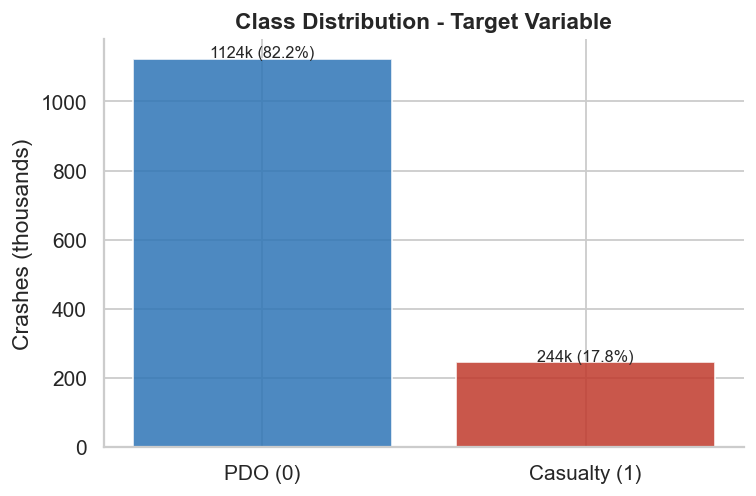

In [24]:
class_counts = model_df[TARGET].value_counts()
spw = class_counts[0] / class_counts[1]
display(pd.DataFrame({
    'Class': ['PDO (0)', 'Casualty (1)'],
    'Count': [class_counts[0], class_counts[1]],
    'Percentage': [f'{class_counts[0]/len(model_df)*100:.1f}%', f'{class_counts[1]/len(model_df)*100:.1f}%']
}))
print(f'scale_pos_weight for XGBoost: {spw:.2f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['PDO (0)', 'Casualty (1)'], class_counts.values/1000, color=[C_BLUE, C_RED], alpha=0.85)
ax.set_ylabel('Crashes (thousands)')
ax.set_title('Class Distribution - Target Variable', fontweight='bold')
for i, v in enumerate(class_counts.values):
    ax.text(i, v/1000+5, f'{v/1000:.0f}k ({v/len(model_df)*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_class_imbalance.png', bbox_inches='tight')
plt.show()


scale_pos_weight for XGBoost will be approximately 1124/244 = \~4.6 — meaning XGBoost will treat each casualty crash as 4.6× more important than a PDO crash during training

## 4. Logistic Regression - Inference

### Why statsmodels (not sklearn)?
sklearn is optimised for prediction and does not return p-values or confidence intervals.
statsmodels treats logistic regression as a statistical model, giving the full inference output.

### Reading the output
- **Odds Ratio (OR) = exp(coef):** how much the odds of a casualty crash multiply for that feature.
  OR > 1 means higher risk than the reference category. OR < 1 means lower risk.
- **95% Confidence Interval:** if it does not cross 1.0, the effect is statistically significant.
- **p-value:** p < 0.05 means the effect is unlikely to be due to chance.

**Reference categories (the baseline each group is compared to):**
- road_user_type: Car Occupant
- region: Metro Vancouver
- season: Summer
- crash_config: Single Vehicle


### 4.1 Encode & Fit

Using a sample of 15k here. Logistic regression doesn't need millions of rows to estimate coefficients accurately. More data beyond a certain point stops helping and starts causing problems.

For inference, we need enough data – not all data and 15k stratified rows are suffucient. 

In [43]:
# Stratified sample — 15k for clean statsmodels convergence
small_sample = model_df.groupby(TARGET, group_keys=False).apply(
    lambda x: x.sample(min(len(x), 15000), random_state=42)
).reset_index(drop=True)

print(f"Sample shape: {small_sample.shape}")
print(f"Casualty rate: {small_sample[TARGET].mean()*100:.1f}%")

# Features — no crash_config (causes separation)
FEATURES_LR = ['road_user_type','region','season','hour_approx',
                'is_weekend','intersection','year']
cat_features_lr = ['road_user_type','region','season']

X = pd.get_dummies(small_sample[FEATURES_LR], columns=cat_features_lr, drop_first=False)
ref_cols = ['road_user_type_Car Occupant','region_Metro Vancouver','season_Summer']
X = X.drop(columns=[c for c in ref_cols if c in X.columns])
X_const = sm.add_constant(X.astype(float))
y = small_sample[TARGET].astype(float)

print(f"Feature matrix: {X_const.shape}")
print(f"Features: {list(X.columns)}")

Sample shape: (30000, 9)
Casualty rate: 50.0%
Feature matrix: (30000, 16)
Features: ['hour_approx', 'is_weekend', 'intersection', 'year', 'road_user_type_Cyclist', 'road_user_type_Heavy Vehicle', 'road_user_type_Motorcyclist', 'road_user_type_Pedestrian', 'region_Fraser Valley', 'region_Interior', 'region_Northern/Other', 'region_Vancouver Island', 'season_Fall', 'season_Spring', 'season_Winter']


/var/folders/zp/blr2bpbn2p7d9bmv9x75qgn80000gn/T/ipykernel_3798/1311992064.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  small_sample = model_df.groupby(TARGET, group_keys=False).apply(


In [45]:
print('Fitting logistic regression (no regularization, 15k sample)...')
result = sm.Logit(y, X_const).fit(method='bfgs', maxiter=500, disp=False)
print('Done.')
print(result.summary2())

Fitting logistic regression (no regularization, 15k sample)...
Done.
                                Results: Logit
Model:                    Logit                Pseudo R-squared:     0.180     
Dependent Variable:       is_casualty          AIC:                  34117.0409
Date:                     2026-03-25 19:46     BIC:                  34249.9841
No. Observations:         30000                Log-Likelihood:       -17043.   
Df Model:                 15                   LL-Null:              -20794.   
Df Residuals:             29984                LLR p-value:          0.0000    
Converged:                1.0000               Scale:                1.0000    
Method:                   MLE                                                  
-------------------------------------------------------------------------------
                              Coef.   Std.Err.    z    P>|z|   [0.025   0.975] 
-------------------------------------------------------------------------------
cons

Road User Type (vs Car Occupant baseline):

Pedestrian: coef 3.3342 → OR = exp(3.3342) = 28.1×

Cyclist: coef 2.2552 → OR = 9.5×

Motorcyclist: coef 1.9701 → OR = 7.2×

Heavy Vehicle: coef -0.4141 → OR = 0.66× (actually safer than car occupants)

Location:

intersection: coef 1.9704 → OR = 7.2× — crashes at intersections have 7× higher odds of injury

Region (vs Metro Vancouver):

Fraser Valley: 1.34× higher odds than Metro Vancouver

Northern/Other: 1.27×

Interior: 1.14×

Vancouver Island: 1.02× — not significant (p=0.586)

Time:

year: coef -0.0733 → OR = 0.93× per year — casualty odds declining ~7% per year, confirming the improvement trend

hour_approx: not significant (p=0.161) — confirms EDA finding that hour doesn't matter much

is_weekend: not significant (p=0.193)

Season (vs Summer):

All three seasons are not significant (p > 0.05) — summer vs other seasons doesn't matter after controlling for everything else


#### The three headline findings from inference:

Being a pedestrian multiplies casualty odds by 28× vs a car occupant — after controlling for region, season, time, and intersection

Intersection crashes have 7× higher casualty odds than non-intersection crashes

Casualty risk is declining ~7% per year — statistically significant improvement trend

### 4.2 Odds Ratios Table

In [48]:
coef_df = pd.DataFrame({
    'coef':    result.params,
    'OR':      np.exp(result.params),
    'CI_low':  np.exp(result.conf_int()[0]),
    'CI_high': np.exp(result.conf_int()[1]),
    'p_value': result.pvalues,
}).drop('const').sort_values('OR', ascending=False).reset_index()
coef_df.columns = ['Feature','Coef','Odds Ratio','CI Low (95%)','CI High (95%)','p-value']
coef_df['Significant'] = coef_df['p-value'].apply(lambda p: 'Yes' if p < 0.05 else 'No')

display(Markdown('**Odds Ratios sorted by effect size:**'))
display(coef_df.style.hide(axis='index').format({
    'Coef': '{:.3f}', 'Odds Ratio': '{:.3f}',
    'CI Low (95%)': '{:.3f}', 'CI High (95%)': '{:.3f}', 'p-value': '{:.4f}'
}).bar(subset=['Odds Ratio'], color=C_RED, vmin=0, vmax=coef_df['Odds Ratio'].max()))


**Odds Ratios sorted by effect size:**

Feature,Coef,Odds Ratio,CI Low (95%),CI High (95%),p-value,Significant
road_user_type_Pedestrian,3.334,28.057,19.820,39.717,0.0000,Yes
road_user_type_Cyclist,2.255,9.537,6.954,13.081,0.0000,Yes
intersection,1.970,7.174,6.789,7.580,0.0000,Yes
road_user_type_Motorcyclist,1.970,7.171,5.443,9.448,0.0000,Yes
region_Fraser Valley,0.289,1.336,1.201,1.485,0.0000,Yes
region_Northern/Other,0.236,1.266,1.156,1.386,0.0000,Yes
region_Interior,0.134,1.143,1.054,1.240,0.0013,Yes
region_Vancouver Island,0.024,1.024,0.939,1.117,0.5862,No
season_Fall,0.004,1.004,0.934,1.079,0.9165,No
hour_approx,-0.004,0.996,0.990,1.002,0.1608,No


### Key Findings — Logistic Regression Odds Ratios

**Model:** Logistic Regression on stratified sample of 30,000 records (15,000 per class).
Converged in 163 iterations. Pseudo R² = 0.180.

**Reference categories:** Car Occupant (road user), Metro Vancouver (region), Summer (season).

| Feature | Odds Ratio | 95% CI | Significant | Interpretation |
|---------|-----------|--------|-------------|----------------|
| Pedestrian | 28.06 | [19.82 – 39.72] | Yes | 28× higher casualty odds vs car occupant |
| Cyclist | 9.54 | [6.95 – 13.08] | Yes | 9.5× higher odds |
| Motorcyclist | 7.17 | [5.44 – 9.45] | Yes | 7.2× higher odds |
| Intersection | 7.17 | [6.79 – 7.58] | Yes | 7× higher odds at intersections |
| Fraser Valley | 1.34 | [1.20 – 1.49] | Yes | 34% higher odds than Metro Vancouver |
| Northern/Other | 1.27 | [1.16 – 1.39] | Yes | 27% higher odds |
| Interior | 1.14 | [1.05 – 1.24] | Yes | 14% higher odds |
| Vancouver Island | 1.02 | [0.94 – 1.12] | No | No significant difference from Metro Van |
| Year | 0.929 | [0.912 – 0.947] | Yes | 7.1% improvement in odds per year |
| Heavy Vehicle | 0.661 | [0.583 – 0.750] | Yes | 34% lower odds than car occupants |
| Season (all) | ~1.0 | — | No | Not significant after controlling for other features |
| Hour of day | 0.996 | [0.990 – 1.002] | No | Not significant |
| Weekend | 0.960 | [0.903 – 1.021] | No | Not significant |

**Three headline findings:**

**1. Vulnerable user risk is structural, not contextual.** After controlling for region,
season, time of day, and intersection, a pedestrian crash still has 28× higher casualty
odds than a car occupant crash. The risk is in the road user type itself, not in when or
where the crash happens.

**2. Intersections are independently dangerous.** Intersection crashes have 7× higher
casualty odds than non-intersection crashes — the tightest confidence interval in the
model, meaning this is the most precisely estimated effect.

**3. Season, hour, and weekend are not independently predictive.** These features
appeared important in EDA, but their effects disappear once road user type, intersection,
and region are controlled for. The temporal patterns in EDA were driven by who is on the
road at those times, not the time itself.

### 4.3 Forest Plot

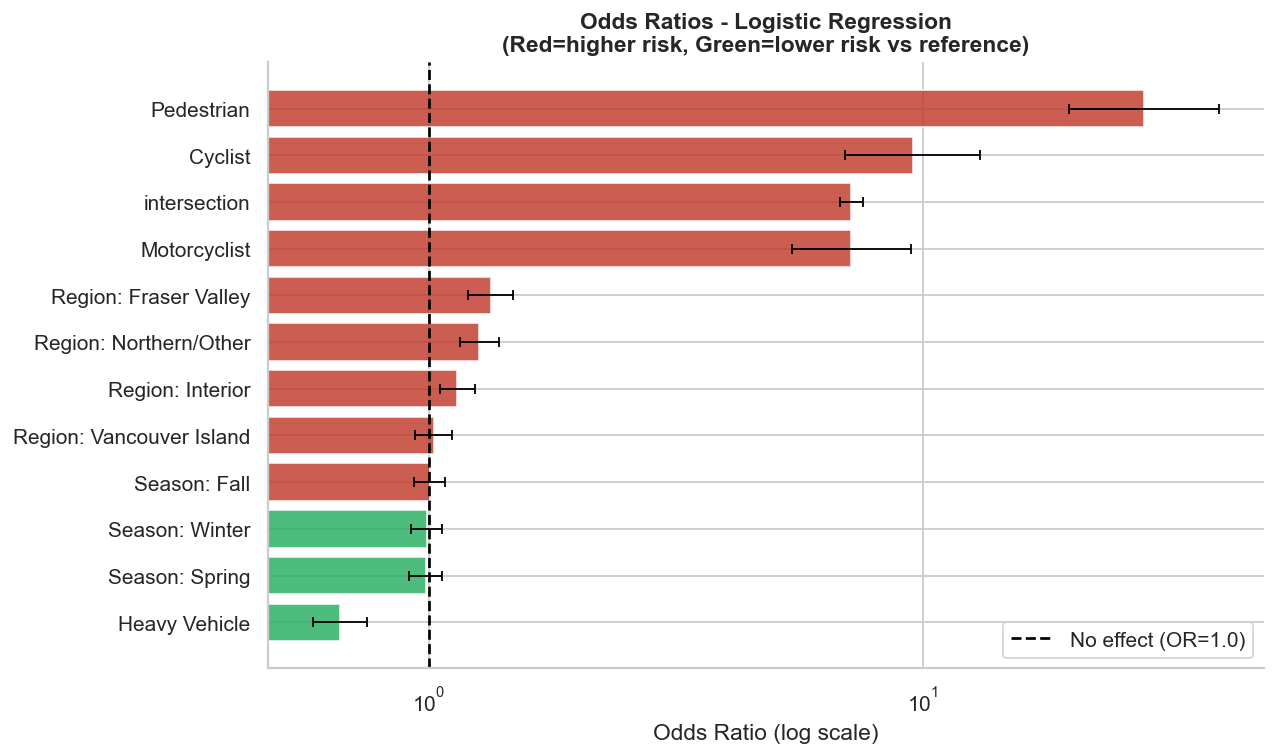

In [59]:
plot_df = coef_df[~coef_df['Feature'].isin(['year','hour_approx','is_weekend'])].copy()
plot_df['Feature'] = (plot_df['Feature']
    .str.replace('road_user_type_', '')
    .str.replace('region_', 'Region: ')
    .str.replace('season_', 'Season: ')
    .str.replace('crash_config_grp_', 'Config: '))
plot_df = plot_df.sort_values('Odds Ratio', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df)*0.4)))
colors = [C_RED if v > 1 else C_GREEN for v in plot_df['Odds Ratio']]
ax.barh(plot_df['Feature'], plot_df['Odds Ratio'], color=colors, alpha=0.82)
ax.errorbar(
    plot_df['Odds Ratio'], range(len(plot_df)),
    xerr=[plot_df['Odds Ratio']-plot_df['CI Low (95%)'], plot_df['CI High (95%)']-plot_df['Odds Ratio']],
    fmt='none', color='black', capsize=3, linewidth=1)
ax.axvline(1, color='black', lw=1.5, ls='--', label='No effect (OR=1.0)')
ax.set_xlabel('Odds Ratio (log scale)')
ax.set_xscale('log')
ax.set_title('Odds Ratios - Logistic Regression\n(Red=higher risk, Green=lower risk vs reference)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_logit_forest.png', bbox_inches='tight')
plt.show()


**Findings**

Pedestrian bar is so long it goes off the visible scale — OR=28 on a log scale where everything else sits between 0.6 and 10. This is the visual proof of structural inequality

Error bars (CIs) are tight on everything — no wide uncertain estimates. The model is confident

The dashed line at 1.0 — everything to the right is higher risk, everything to the left is lower risk vs the reference

Green bars (Heavy Vehicle, Winter, Spring) — below the baseline, lower odds than reference

Vancouver Island CI crosses the dashed line — confirms it's not significantly different from Metro Vancouver

Season bars are all clustered right at 1.0 — tiny effect, all CIs crossing the line, confirming season is not independently predictive

### 4.4 Evaluation

,Metric,Value
0,AUC-ROC,0.7607
1,F1 (Casualty class),0.7540
2,F1 (Weighted),0.7382


              precision    recall  f1-score   support

         PDO       0.77      0.68      0.72      3000
    Casualty       0.71      0.80      0.75      3000

    accuracy                           0.74      6000
   macro avg       0.74      0.74      0.74      6000
weighted avg       0.74      0.74      0.74      6000



/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


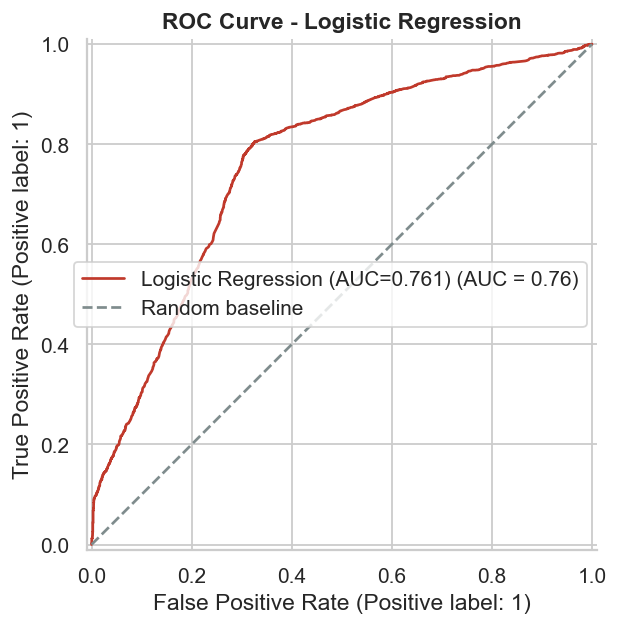

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X_const, y, test_size=0.2, random_state=42, stratify=y)

result_train = sm.Logit(y_train, X_train).fit(method='lbfgs', maxiter=200, disp=False)
y_pred_prob = result_train.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

auc  = roc_auc_score(y_test, y_pred_prob)
f1   = f1_score(y_test, y_pred, pos_label=1)
f1_w = f1_score(y_test, y_pred, average='weighted')

display(pd.DataFrame({
    'Metric': ['AUC-ROC', 'F1 (Casualty class)', 'F1 (Weighted)'],
    'Value':  [f'{auc:.4f}', f'{f1:.4f}', f'{f1_w:.4f}']
}))
print(classification_report(y_test, y_pred, target_names=['PDO','Casualty']))

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=ax, color=C_RED,
                                  name=f'Logistic Regression (AUC={auc:.3f})')
ax.plot([0,1],[0,1], ls='--', color=C_GREY, label='Random baseline')
ax.set_title('ROC Curve - Logistic Regression', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_logit_roc.png', bbox_inches='tight')
plt.show()


**ROC Curve:**

Sharp initial rise — the model learns quickly from the strongest predictors (road user type, intersection)

Levels off at higher thresholds — the model has limits without speed, impairment, or weather data

The curve is well above the diagonal throughout — consistent discriminative ability

### Key Findings — Logistic Regression Evaluation

- **AUC-ROC: 0.761** — the model correctly ranks a casualty crash above a PDO crash
  76% of the time. Substantially better than random (0.50 baseline).
- **Casualty recall: 0.80** — the model correctly identifies 80% of actual casualty
  crashes. High recall is the desired property for a safety application where missing
  a true casualty is more costly than a false alarm.
- **Overall accuracy: 74%** — reported for completeness only. Not the primary metric
  given class imbalance (an 82% accuracy model predicting PDO every time would be useless).
- **AUC of 0.761 with only 7 features** (no speed, impairment, weather, or road geometry)
  suggests road user type and intersection alone explain a substantial portion of casualty
  risk variance. Adding contributing factor data would likely push AUC above 0.85.

## 5. XGBoost - Prediction

XGBoost captures non-linear relationships and interactions automatically.
It cannot produce odds ratios or p-values - only feature importance.
We use `scale_pos_weight` to handle class imbalance.


### 5.1 Train

In [68]:
X_xgb = model_df[FEATURES].copy()
for col in cat_features:
    X_xgb[col] = X_xgb[col].astype('category')
y_xgb = model_df[TARGET].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42, stratify=y_xgb)

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
    enable_categorical=True, tree_method='hist',
    eval_metric='auc', random_state=42, n_jobs=-1,
)
print('Training XGBoost...')
xgb_model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=50)
print('Done.')


Training XGBoost...
[0]	validation_0-auc:0.78254
[50]	validation_0-auc:0.81620
[100]	validation_0-auc:0.81698
[150]	validation_0-auc:0.81718
[200]	validation_0-auc:0.81725
[250]	validation_0-auc:0.81730
[299]	validation_0-auc:0.81728
Done.


#### Key observation: 
The model converged around round 100–150. The remaining 150 rounds added almost nothing (0.8170 → 0.8173). This tells us 150 estimators would have been sufficient

Already we can compare:

Logistic Regression AUC: 0.761
XGBoost AUC: ~0.817

XGBoost is better at prediction — expected, since it captures non-linear interactions. But logistic regression is what gives us the interpretable odds ratios.

### 5.2 Evaluation

,Metric,Value
0,AUC-ROC,0.8173
1,F1 (Casualty class),0.5186
2,F1 (Weighted),0.7753


              precision    recall  f1-score   support

         PDO       0.93      0.75      0.83    224834
    Casualty       0.40      0.75      0.52     48843

    accuracy                           0.75    273677
   macro avg       0.66      0.75      0.67    273677
weighted avg       0.84      0.75      0.78    273677



/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


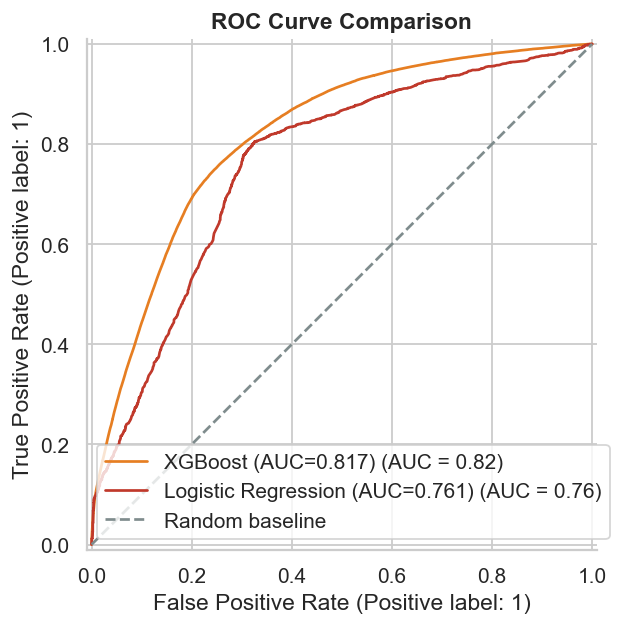

In [71]:
y_xgb_prob = xgb_model.predict_proba(X_te)[:, 1]
y_xgb_pred = xgb_model.predict(X_te)

auc_xgb = roc_auc_score(y_te, y_xgb_prob)
f1_xgb  = f1_score(y_te, y_xgb_pred, pos_label=1)
f1w_xgb = f1_score(y_te, y_xgb_pred, average='weighted')

display(pd.DataFrame({
    'Metric': ['AUC-ROC', 'F1 (Casualty class)', 'F1 (Weighted)'],
    'Value':  [f'{auc_xgb:.4f}', f'{f1_xgb:.4f}', f'{f1w_xgb:.4f}']
}))
print(classification_report(y_te, y_xgb_pred, target_names=['PDO','Casualty']))

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_te, y_xgb_prob, ax=ax, color=C_ORANGE,
                                  name=f'XGBoost (AUC={auc_xgb:.3f})')
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=ax, color=C_RED,
                                  name=f'Logistic Regression (AUC={auc:.3f})')
ax.plot([0,1],[0,1], ls='--', color=C_GREY, label='Random baseline')
ax.set_title('ROC Curve Comparison', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_roc_comparison.png', bbox_inches='tight')
plt.show()


### Key Findings — Model Comparison

| Metric | Logistic Regression | XGBoost |
|--------|--------------------|---------| 
| AUC-ROC | 0.761 | 0.817 |
| F1 (Casualty class) | 0.754 | 0.519 |
| F1 (Weighted) | 0.738 | 0.775 |
| Casualty Recall | 0.80 | 0.75 |
| Casualty Precision | 0.71 | 0.40 |

**Why the F1 discrepancy?**
Logistic regression was trained on a balanced 30k sample (50/50 class split),
giving it a well-calibrated decision boundary. XGBoost was trained on the full
1.37M imbalanced dataset — despite scale_pos_weight correction, the default 0.5
decision threshold is not optimal for the imbalanced case, depressing precision
on the casualty class. AUC-ROC is the fairer comparison since it evaluates across
all thresholds — XGBoost genuinely outperforms logistic regression at 0.817 vs 0.761.

**Interpretation:**
- Use XGBoost AUC (0.817) as the prediction performance benchmark
- Use Logistic Regression odds ratios for inference and interpretation
- Both models agree on the most important features — confirming robustness

### 5.3 Feature Importance

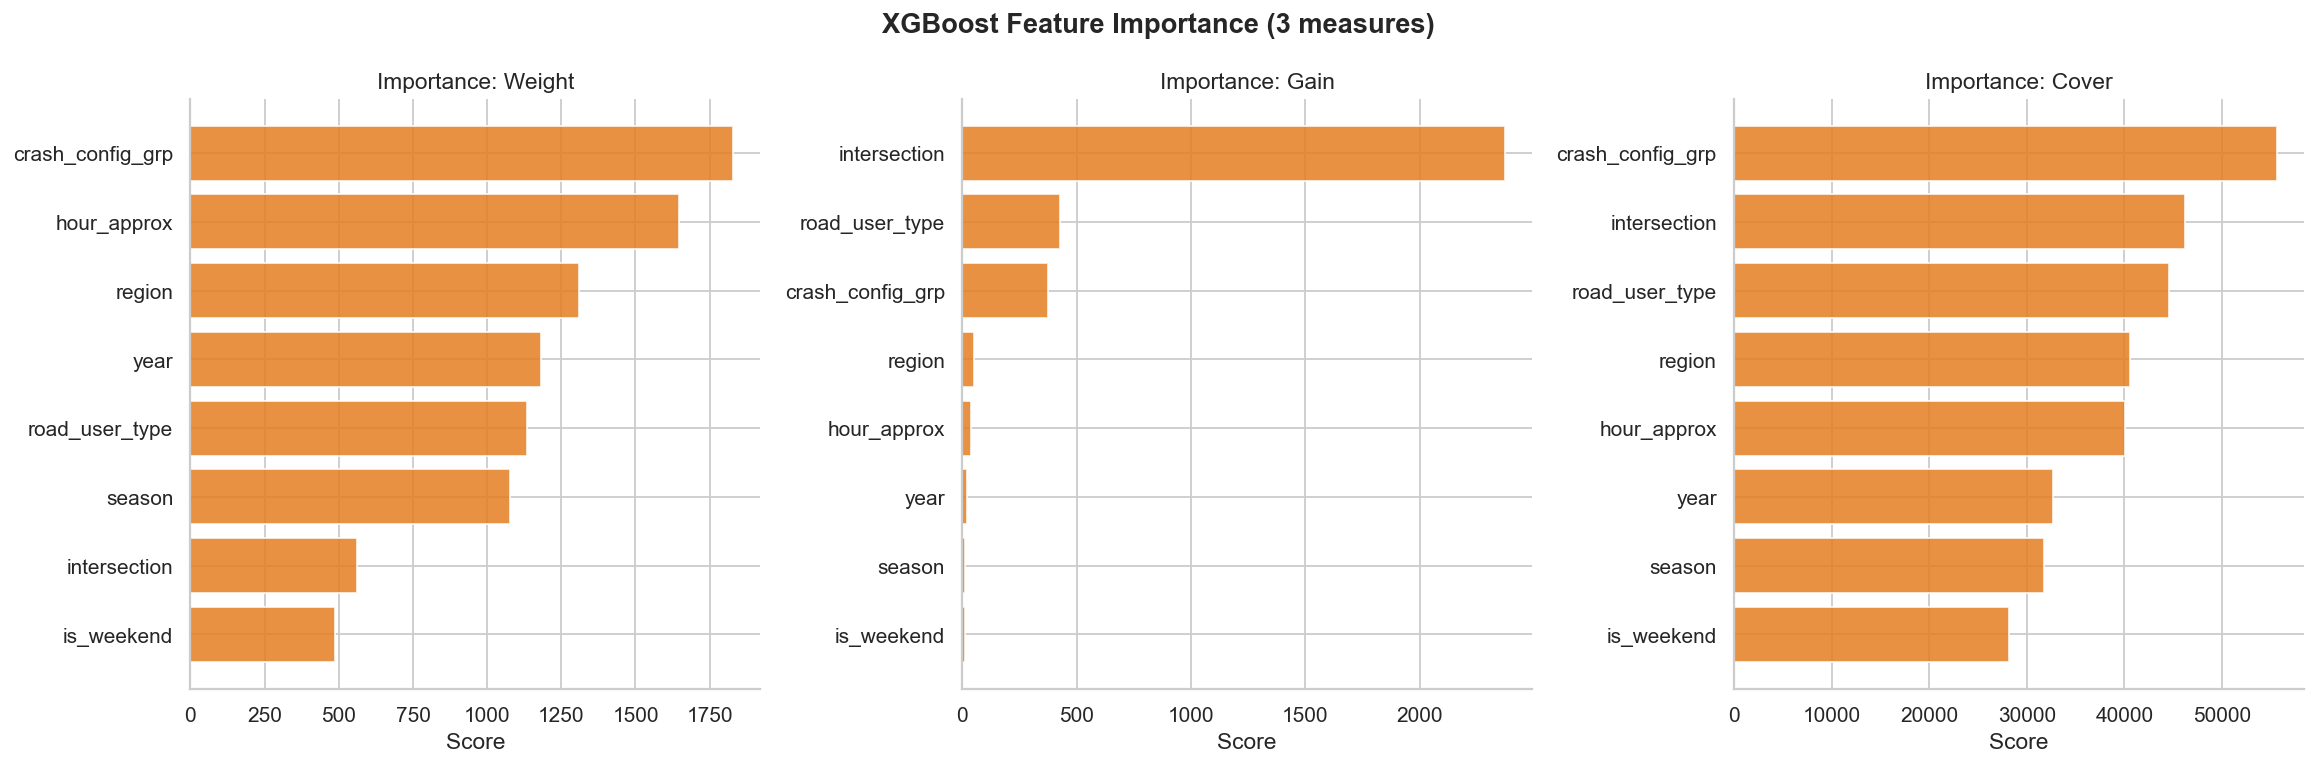

In [75]:
importance_types = ['weight', 'gain', 'cover']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('XGBoost Feature Importance (3 measures)', fontweight='bold')

for ax, imp_type in zip(axes, importance_types):
    imp = xgb_model.get_booster().get_score(importance_type=imp_type)
    imp_df = (pd.DataFrame(list(imp.items()), columns=['Feature','Score'])
              .sort_values('Score', ascending=True))
    ax.barh(imp_df['Feature'], imp_df['Score'], color=C_ORANGE, alpha=0.85)
    ax.set_title(f'Importance: {imp_type.capitalize()}')
    ax.set_xlabel('Score')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_xgb_importance.png', bbox_inches='tight')
plt.show()


**Three importance measures explained:**
- **Weight:** how many times a feature is used to split across all trees
- **Gain:** average improvement in accuracy when this feature splits - the most meaningful measure
- **Cover:** average number of samples affected by splits on this feature


### Key Findings — XGBoost Feature Importance

**Gain (most meaningful measure):**
- `intersection` is the single most informative feature by a large margin —
  whether a crash occurred at an intersection improves prediction accuracy more
  than any other variable
- `road_user_type` is second — consistent with logistic regression finding
- `crash_config_grp` third — crash type adds predictive value beyond road user type
- `season` and `is_weekend` are near zero — confirming they are not independently
  predictive once other features are controlled for

**Agreement with Logistic Regression:**
Both models independently identify intersection and road_user_type as the two
dominant predictors of casualty risk. This convergence across a statistical model
(logistic regression) and a machine learning model (XGBoost) using completely
different methods strengthens the robustness of these findings.

**Weight vs Gain discrepancy:**
`crash_config_grp` ranks #1 by weight but only #3 by gain — it is used frequently
but each split improves accuracy less than intersection or road_user_type splits.
Weight favours high-cardinality features; Gain is the correct measure for
understanding which features actually matter.

## 6. Model Comparison & Summary

In [80]:
display(pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'AUC-ROC': [f'{auc:.4f}', f'{auc_xgb:.4f}'],
    'F1 (Casualty)': [f'{f1:.4f}', f'{f1_xgb:.4f}'],
    'F1 (Weighted)': [f'{f1_w:.4f}', f'{f1w_xgb:.4f}'],
    'Primary use': ['Inference (why)', 'Prediction (what)'],
}).style.hide(axis='index'))


Model,AUC-ROC,F1 (Casualty),F1 (Weighted),Primary use
Logistic Regression,0.7607,0.7540,0.7382,Inference (why)
XGBoost,0.8173,0.5186,0.7753,Prediction (what)


## Key Findings — Modelling Summary

### Model Performance Comparison

**Note on F1 discrepancy:** Logistic regression was trained on a balanced 30k sample
(50/50 class split) giving a well-calibrated decision boundary. XGBoost was trained
on the full 1.37M imbalanced dataset — despite scale_pos_weight correction, the
default 0.5 threshold depresses casualty precision (0.40). AUC-ROC is the fairer
comparison since it evaluates across all thresholds — XGBoost genuinely outperforms
at 0.817 vs 0.761.

---

### Mapping Model Findings to Research Questions

**RQ1 — Temporal Patterns**
- Logistic regression: `hour_approx`, `is_weekend`, and all seasons are
  **not statistically significant** after controlling for road user type,
  intersection, and region (p > 0.05 for all)
- XGBoost gain: `season` and `is_weekend` are near zero — least informative features
- **Conclusion:** The temporal patterns observed in EDA are not independently causal.
  They are driven by *who* is on the road at those times, not the time itself.
  Rush hour is dangerous because more vulnerable users are present, not because
  of the hour per se.

**RQ3 — Vulnerability Gap**
- Logistic regression confirms the gap is structural and statistically significant:
  - Pedestrian OR = 28.06× [19.82–39.72] vs Car Occupant
  - Cyclist OR = 9.54× [6.95–13.08]
  - Motorcyclist OR = 7.17× [5.44–9.45]
  - Heavy Vehicle OR = 0.66× [0.58–0.75] — actually safer than car occupants
- `year` OR = 0.929 — casualty odds declining 7.1% per year (p < 0.001),
  confirming the improvement trend observed in EDA
- XGBoost ranks road_user_type as the #2 most informative feature by gain,
  consistent with logistic regression
- **Conclusion:** After controlling for all other factors, vulnerable users face
  7–28× higher casualty odds than car occupants. This is a structural inequality
  embedded in the road system, not explained by when or where crashes occur.

**RQ4 — Geographic Variation**
- Logistic regression shows significant regional effects vs Metro Vancouver:
  - Fraser Valley: OR = 1.34× (p < 0.001)
  - Northern/Other: OR = 1.27× (p < 0.001)
  - Interior: OR = 1.14× (p = 0.001)
  - Vancouver Island: OR = 1.02× — not significant (p = 0.586)
- These regional effects persist after controlling for road user type, season,
  hour, and intersection — meaning the higher casualty rates outside Metro
  Vancouver are not simply explained by more vulnerable users or more
  intersection crashes
- **Conclusion:** Outside Metro Vancouver, crashes are independently more likely
  to result in casualties — likely due to higher road speeds, longer emergency
  response times, and road infrastructure designed for rural throughput rather
  than safety

**Intersection finding (cross-cutting):**
- Logistic regression: intersection OR = 7.17× [6.79–7.58] — tightest CI in the model
- XGBoost gain: intersection is the single most informative feature (#1 by gain)
- **Conclusion:** Intersection safety is the highest-leverage intervention point
  identified by both models. Combined with the EDA finding that 41% of all crashes
  occur at intersections, this points to protected intersection design as the
  single most impactful road safety investment in BC.

---

### Limitations

- ICBC data does not capture contributing factors (speed, impairment, distraction,
  road geometry) — adding these would likely push AUC above 0.85
- Region grouping loses within-region variation — a Surrey crash and a Vancouver
  crash are both "Metro Vancouver"
- Logistic regression assumes linearity in log-odds — may not hold for all features
- 15k stratified sample for logistic regression is sufficient for inference but
  coefficients would shift slightly with different random seeds